# Custom Eccentricity Distribution

In addition to the built-in eccentricity profiles, the package allows users to define and use their own custom eccentricity distributions by directly using the `EccentricityDistributtion` class. This feature offers maximum flexibility for experimentation and model-specific behaviour. 

The way to use this class depends on whether the user-supplied function is properly normalised (this makes the computations significantly easier). Due to the increased complexity, we break this section into multiple components.

## Initialising with a Normalised $\psi_e(e,a)$ Distribution

If your distribution is already **correectly normalised**, the process simplifies significantly. You can pass your function directly to the `EccentricityDistribution` class and set `auto_normalise=False` (default). In this case, no gridding, interpolation, or numerical integration is performed. Instead, the analytic function is stored and used directly when calculating the kernel.

> See the Kernel section for how this function is evaluated during the surface density calculation.

The user must still define `a_min` and `a_max`, and may optionally specify `num_e_points` and `num_a_points` (defaults to 1000), which are used only for plotting purposes and do not affect the underlying computation.

**This is the most efficient mode of operation, but should only be used if the user can guarantee that the input is correctly normalised.**

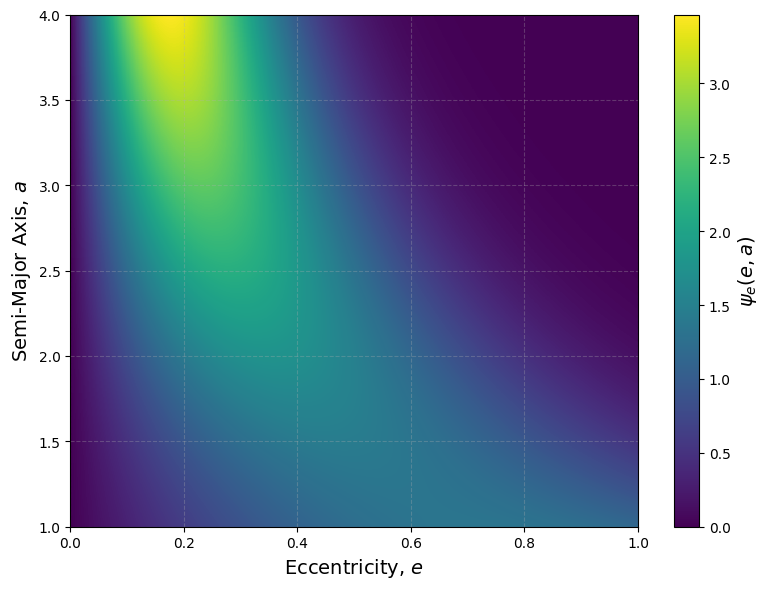

In [1]:
from debrispy import EccentricityDistribution
import numpy as np

def normalised_rayleigh(e, a, sigma0, alpha, a_min):
    sigma = sigma0 * (a_min / a)**alpha
    return (e / sigma**2) * np.exp(-e**2 / (2 * sigma**2)) / (1 - np.exp(-1/(2*sigma**2)))

ecc_rayleigh = EccentricityDistribution(a_min=1, a_max=4, 
                distribution_func=lambda e, a: normalised_rayleigh(e, a, sigma0=0.7, alpha=1, a_min=1),
                auto_normalise = False)

ecc_rayleigh.plot()

## Initialising with an Unnormalised $\psi_e(e,a)$ Distribution

If your function $\psi_e(e,a)$ is not normalised in $e$ for every $a$, but you still want to use it, you can enable the `auto_normalise=True` flag. In this mode, the function will be automatically normalised across the eccentricity domain $[0, 1]$ at every sampled value of $a$ via numerical integration.

In this mode, **gridding becomes essential**. The function must be evaluated on a 2D grid over $(e, a)$ before normalisation, and the result must be stored in a format that allows fast evaluation later. This is accomplished via interpolation, which transforms the gridded function into a callable object.

To control this behaviour, the user must specify:

1. The grid resolution: `num_e_points`, `num_a_points` (default: 1000 each)
2. The grid structure: see Gridding Options below
3. The interpolation method: see Interpolation Options below
4. The grid refinement (only for `warped` and `adaptive` grid types): `grid_spread`, which controls how sharply the grid adapts to features (larger values produce smoother transitions / less build up in sharp regions)

### Gridding Options

When `auto_normalise=True`, a 2D grid is constructed over the $(e, a)$ domain. The user controls the grid using:

- `num_e_points` (default: 1000)
- `num_a_points` (default: 1000)
- `grid_type` (required if `auto_normalise` is True)
- `grid_spread` (default: 1.0)

Supported `grid_type` values include:

| Grid Type   | Description |
|-------------|-------------|
| `'uniform'` | Standard uniform grid over both $e$ and $a$. <br>Best for smooth, slowly varying distributions that cover most of the range. |
| `'warped'`  | Builds a grid that adapts based on the total gradient <br>of the distribution across the entire domain. <br>Useful for resolving sharp features aligned along the $e$ or $a$ axes. |
| `'adaptive'` | Builds a per-column adaptive $e$-grid for each sampled value of $a$. <br>Ideal for handling highly localised structure or features <br>not aligned with coordinate axes. |


In all cases, the grid must be at least semi-structured in $e$ to allow integration and normalisation. This is why fully unstructured methods like quadtrees are not supported. A schematic displaying the different grid types can be seen below, where the blue shaded parts represent steep regions.

![Schematic showing different grid types](_static/grids.jpeg)

> For those interested in the details of the warping and adaptive algorithms, the implementation is fully accessible in the API and source code. See the `EccentricityDistribution._create_grid` method for details.



### Interpolation Options

Once gridded, the normalised distribution is stored as a 2D interpolator. This is necessary for future steps when the Kernel is calculate via integration. The interpolation method is controlled via the `interpolation_method` argument, which supports:

- `'nearest'` (for step-like functions)
- `'linear'` (default and recommended for most cases)
- `'cubic'` (for smooth functions, slower than linear)

Linear interpolation is typically sufficient and balances speed with smoothness. Since the grids are semi-structured by definition, we find it computationally more efficient to use `scipy.interpolate.interp1d` per row (i.e., per sampled value of semi-major axis).

## Examples with Different Grid Types

This section demonstrates the different gridding options, on purpose with a low resolution (100 points for $e$ and $a$), so that it is very apparent how the grid works.

### Example 1: Using `uniform` Grid

For smooth, slow-varying, functions a `uniform` grid is sufficient, and simple to compute. In this example, we consider the Rayeligh distribution.

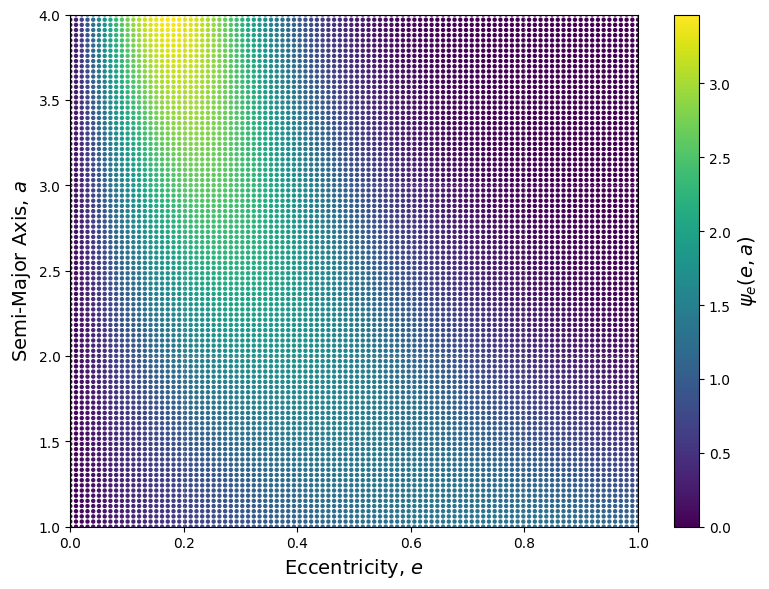

In [2]:
def unnormalised_rayleigh(e, a, sigma0, alpha, a_min):
    sigma = sigma0 * (a_min / a)**alpha
    return (e / sigma**2) * np.exp(-e**2 / (2 * sigma**2))

ecc_rayleigh = EccentricityDistribution(a_min=1, a_max=4, 
                    distribution_func=lambda e, a: unnormalised_rayleigh(e, a, sigma0=0.7, alpha=1, a_min=1),
                    auto_normalise = True, 
                    num_e_points = 100,
                    num_a_points = 100,
                    grid_type = 'uniform',
                    interpolation_method = 'linear')

ecc_rayleigh.plot(points = True)

### Example 2: Using `warped` Grid

This is useful when there are sharp features aligned with one of the axes. In this example, we consider a thin Gaussian function that is centered at $e=0.5$.  

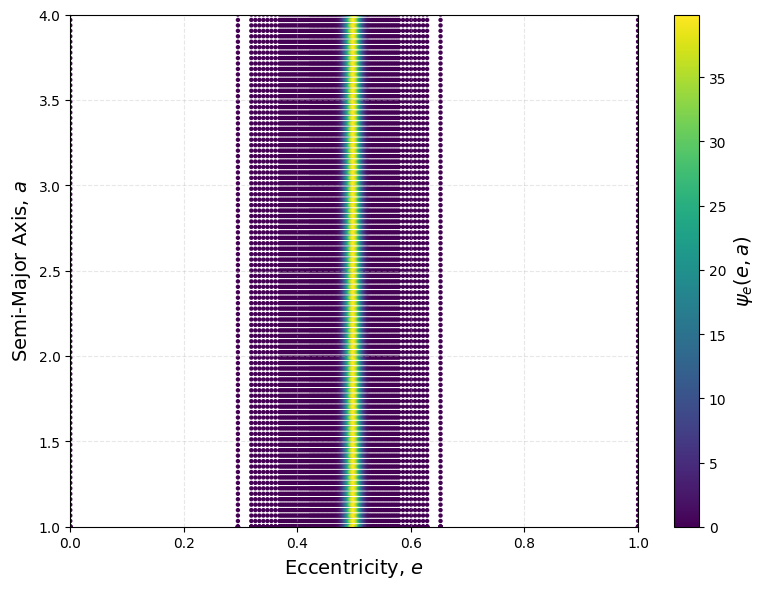

In [3]:
def gauss_along_a(e, a):
    return np.exp(-(e - 0.5)**2 / (2 * 0.01**2))

ecc_rayleigh = EccentricityDistribution(a_min=1, a_max=4, 
                    distribution_func=gauss_along_a,
                    auto_normalise = True, 
                    num_e_points = 100,
                    num_a_points = 100,
                    grid_type = 'adaptive',
                    interpolation_method = 'linear')

ecc_rayleigh.plot(points = True)

### Example 3: Using `adaptive` Grid

The `adaptive` grid takes it a step further, and thanks to a semi-structured grid, can adapt the grid points separately *per $a$ value*. As an example, we consider a Gaussian distribution, where now, the centre is no longer constant but a function of $a$.

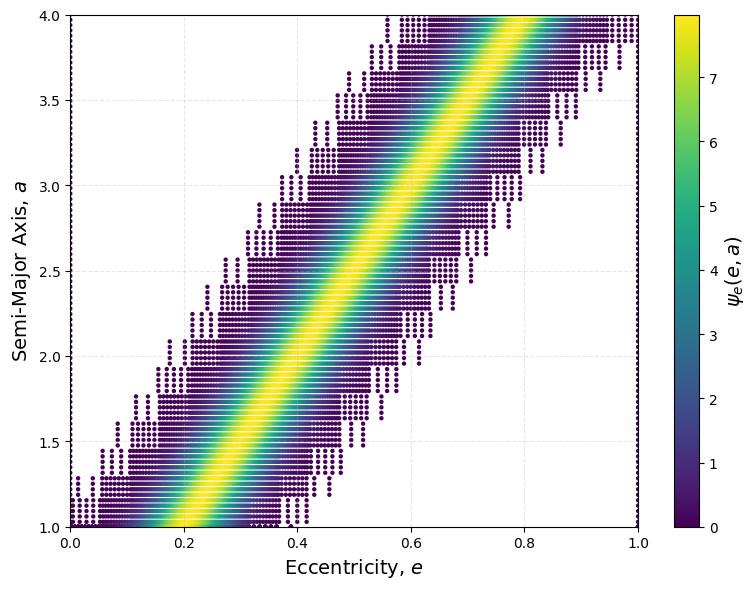

In [4]:
def gauss_along_a(e, a):
    return np.exp(-(e - 0.2*a)**2 / (2 * 0.05**2))

ecc_rayleigh = EccentricityDistribution(a_min=1, a_max=4, 
                    distribution_func=gauss_along_a,
                    auto_normalise = True, 
                    num_e_points = 100,
                    num_a_points = 100,
                    grid_type = 'adaptive',
                    interpolation_method = 'linear')

ecc_rayleigh.plot(points = True)

## Common Functionality

The `EccentricityDistribution` class provides several useful methods for inspection, visualisation, and evaluation of the 2D distribution $\psi_e(e,a)$. These are particularly helpful when `auto_normalise=True`, in which case the distribution is normalised numerically and interpolated.

### Accessing the Distribution Values

To evaluate the distribution at specific values of eccentricity, $e$, and semi-major axis, $a$, one can use the `distribution()` method, which returns the $\psi_e(e, a)$ values evaluated at the chosen points.

Both `e` and `a` can be scalars or NumPy arrays. If arrays are passed, broadcasting is *automatically handled* to return the corresponding grid of values. 

- If `auto_normalise=False`, this directly evaluates the user-provided `distribution_func(e, a)`.
- If `auto_normalise=True`, this returns interpolated and normalised values according to the chosen `interpolation_method`.

**Note:** When both $e$ and $a$ are scalars, the method returns a NumPy array of shape (1,) rather than a pure float. This is for consistency with the vectorised interface.


In [5]:
# Example of a power-law distribution
def gauss_along_a(e, a):
    return np.exp(-(e - 0.5)**2 / (2 * 0.01**2))

ecc_rayleigh = EccentricityDistribution(a_min=1, a_max=4, 
                    distribution_func=gauss_along_a,
                    auto_normalise = True, 
                    num_e_points = 500,
                    num_a_points = 500,
                    grid_type = 'uniform',
                    interpolation_method = 'cubic')

a_vals = np.linspace(2, 3, 5)
e_vals = np.linspace(0, 1, 5)

# This is obtained via interpolating the auto normalised distribution
dist = ecc_rayleigh.distribution(e_vals, a_vals)

print(dist)

[[0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
  0.00000000e+000]
 [7.65392974e-135 7.65392974e-135 7.65392974e-135 7.65392974e-135
  7.65392974e-135]
 [3.98942280e+001 3.98942280e+001 3.98942280e+001 3.98942280e+001
  3.98942280e+001]
 [7.65392974e-135 7.65392974e-135 7.65392974e-135 7.65392974e-135
  7.65392974e-135]
 [0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
  0.00000000e+000]]


### Accessing the Sampled (and Normalised) Grid

The user can access the grid through the `get_sampled_distribution()` method. No interpolation is done on these values.

- When `auto_normalise=True`, this corresponds to the internal gridded data used for interpolation.
- When `auto_normalise=False`, the function is evaluated directly over the pre-set uniform grid (same grid used for plotting).

In [6]:
e_grid, a_grid, psi_grid = ecc_rayleigh.get_sampled_distribution()

### 2D Visualisation

The user can visualise the 2D $\psi_e(e, a)$ distribution as a colourmap, using the `plot()` method over the defined grid.

Supported keyword arguments include:


| Argument                   | Description                                                                 |
|----------------------------|-----------------------------------------------------------------------------|
| `log=True`                 | Enables a logarithmic colour scale.                                        |
| `points=True`              | Visualises the distribution as scatter points rather than a continuous map. |
| `vmin`, `vmax`             | Manually sets the colour scale limits.                                     |
| `save=True`, `filename=…`  | Saves the plot to the specified filename instead of displaying it.         |
| `cmap`                     | The colourmap to use when plotting. (Default: Viridis)                            |

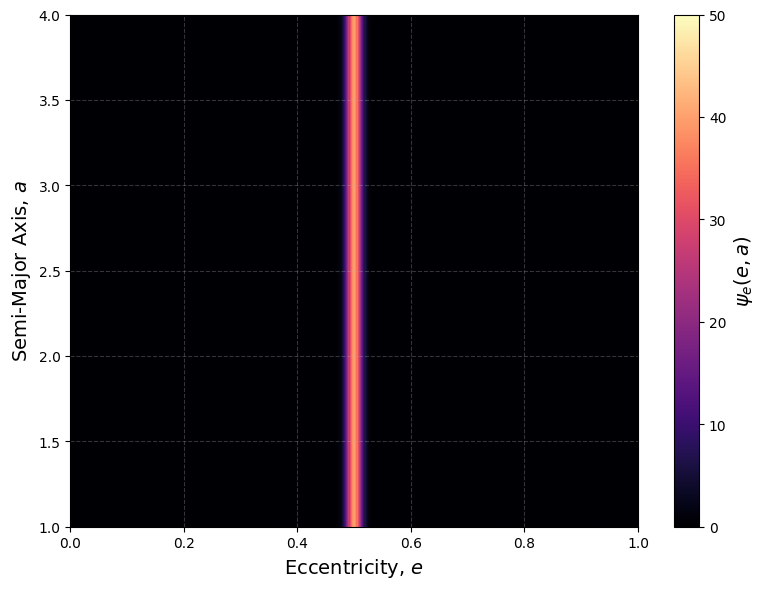

In [7]:
ecc_rayleigh.plot(cmap = 'magma', log = False, vmin = 0, vmax = 50)

### 1D "Slice" Visualisation

The `plot_slice()` method provides a convenient way to visualise **1D slices** of the 2D eccentricity distribution by fixing either the eccentricity or the semi-major axis.

**Usage Options:**

- To plot $\psi_e(e)$ at a fixed semi-major axis $a$, use the `fix_a` keyword.
- To plot $\psi_e(a)$ at a fixed eccentricity $e$, use the `fix_e` keyword.
- **Exactly one** of `fix_a` or `fix_e` must be supplied.

**Default Behaviour:**

- 500 points are sampled by default (`num_points=500`).
- A new figure is created unless an existing `ax` is passed.
- Axis labels, a legend, and gridlines are added automatically.
- The plot is shown by default (`show=True`). To save instead, use `save=True` and specify a `filename`.

**Customisation:**
The plot accepts additional `matplotlib.pyplot.plot()` keyword arguments. Common options include:

| Argument     | Description                                  |
|--------------|----------------------------------------------|
| `color`      | Line colour                                  |
| `linestyle`  | Line style (`'-'`, `'--'`, `':'`, etc.)      |
| `marker`     | Marker style for points                      |
| `linewidth`  | Thickness of the line                        |
| `label`      | Custom legend label                          ||

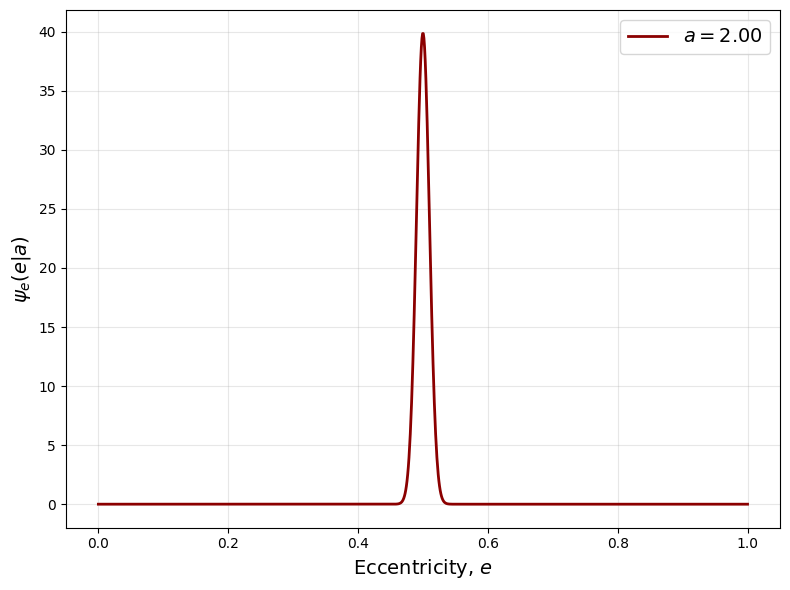

In [8]:
ecc_rayleigh.plot_slice(fix_a = 2, num_points = 1000, linestyle = '-', linewidth = 2, color = 'darkred')

## Additional Notes for `auto_normalise=True`

- In this case, the function is normalised along $e$ for each sampled $a$ and then interpolated.
- The normalisation constants, $N(a)$ are interpolated internally, using `scipy.interpolate.interp1d`.

Since the resulting grid is always semi-structured (uniform, warped, or adaptive in $e$), we find it is computationally more efficient to use `interp1` row-wise in eccentricity, rather than a fully 2D interpolator.